In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("../data/processed/feature_engineered_energy_data.csv")

In [27]:
df.head()

,DateTime,Temperature,Humidity,Wind_Speed,General_Diffuse_Flows,Diffuse_Flows,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Hour,...,Zone_3_roll_max_1h,Zone_3_roll_mean_24h,Zone_3_roll_std_24h,Zone_3_roll_min_24h,Zone_3_roll_max_24h,Temp_Humidity_Index,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,...,NaN,NaN,NaN,NaN,NaN,-23.858374,False,False,False,True
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,...,20240.96386,20240.963860,NaN,20240.96386,20240.96386,-24.599243,False,False,False,True
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,...,20240.96386,20186.024100,77.696554,20131.08434,20240.96386,-24.951034,False,False,False,True
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,...,20240.96386,20013.493977,303.839279,19668.43373,20240.96386,-25.795530,False,False,False,True
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,...,20240.96386,19734.939760,609.848625,18899.27711,20240.96386,-26.746187,False,False,False,True


In [28]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 52416
Number of columns: 53


In [29]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['DateTime', 'Temperature', 'Humidity', 'Wind_Speed', 'General_Diffuse_Flows', 'Diffuse_Flows', 'Zone_1_Power_Consumption', 'Zone_2_Power_Consumption', 'Zone_3_Power_Consumption', 'Hour', 'Day_of_Week', 'Month', 'Quarter', 'Is_Weekend', 'Is_Peak_Hour', 'Zone_1_lag_1', 'Zone_1_lag_6', 'Zone_1_lag_144', 'Zone_2_lag_1', 'Zone_2_lag_6', 'Zone_2_lag_144', 'Zone_3_lag_1', 'Zone_3_lag_6', 'Zone_3_lag_144', 'Zone_1_roll_mean_1h', 'Zone_1_roll_std_1h', 'Zone_1_roll_min_1h', 'Zone_1_roll_max_1h', 'Zone_1_roll_mean_24h', 'Zone_1_roll_std_24h', 'Zone_1_roll_min_24h', 'Zone_1_roll_max_24h', 'Zone_2_roll_mean_1h', 'Zone_2_roll_std_1h', 'Zone_2_roll_min_1h', 'Zone_2_roll_max_1h', 'Zone_2_roll_mean_24h', 'Zone_2_roll_std_24h', 'Zone_2_roll_min_24h', 'Zone_2_roll_max_24h', 'Zone_3_roll_mean_1h', 'Zone_3_roll_std_1h', 'Zone_3_roll_min_1h', 'Zone_3_roll_max_1h', 'Zone_3_roll_mean_24h', 'Zone_3_roll_std_24h', 'Zone_3_roll_min_24h', 'Zone_3_roll_max_24h', 'Temp_Humidity_Index', 'Sea

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 53 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DateTime                  52416 non-null  str    
 1   Temperature               52416 non-null  float64
 2   Humidity                  52416 non-null  float64
 3   Wind_Speed                52416 non-null  float64
 4   General_Diffuse_Flows     52416 non-null  float64
 5   Diffuse_Flows             52416 non-null  float64
 6   Zone_1_Power_Consumption  52416 non-null  float64
 7   Zone_2_Power_Consumption  52416 non-null  float64
 8   Zone_3_Power_Consumption  52416 non-null  float64
 9   Hour                      52416 non-null  int64  
 10  Day_of_Week               52416 non-null  int64  
 11  Month                     52416 non-null  int64  
 12  Quarter                   52416 non-null  int64  
 13  Is_Weekend                52416 non-null  int64  
 14  Is_Peak_Hour     

In [31]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
DateTime                      0
Temperature                   0
Humidity                      0
Wind_Speed                    0
General_Diffuse_Flows         0
Diffuse_Flows                 0
Zone_1_Power_Consumption      0
Zone_2_Power_Consumption      0
Zone_3_Power_Consumption      0
Hour                          0
Day_of_Week                   0
Month                         0
Quarter                       0
Is_Weekend                    0
Is_Peak_Hour                  0
Zone_1_lag_1                  1
Zone_1_lag_6                  6
Zone_1_lag_144              144
Zone_2_lag_1                  1
Zone_2_lag_6                  6
Zone_2_lag_144              144
Zone_3_lag_1                  1
Zone_3_lag_6                  6
Zone_3_lag_144              144
Zone_1_roll_mean_1h           1
Zone_1_roll_std_1h            2
Zone_1_roll_min_1h            1
Zone_1_roll_max_1h            1
Zone_1_roll_mean_24h          1
Zone_1_roll_std_24h           2
Zone_1_ro

In [32]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [33]:
df.describe()

,Temperature,Humidity,Wind_Speed,General_Diffuse_Flows,Diffuse_Flows,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Hour,Day_of_Week,...,Zone_2_roll_max_24h,Zone_3_roll_mean_1h,Zone_3_roll_std_1h,Zone_3_roll_min_1h,Zone_3_roll_max_1h,Zone_3_roll_mean_24h,Zone_3_roll_std_24h,Zone_3_roll_min_24h,Zone_3_roll_max_24h,Temp_Humidity_Index
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,...,52415.000000,52415.000000,52414.000000,52415.000000,52415.000000,52415.000000,52414.000000,52415.000000,52415.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.471746,17737.319088,11.500000,3.000000,...,28913.584734,17737.690047,458.099102,17145.986519,18330.188545,17742.181233,4163.269281,10773.948364,25502.837077,16.744079
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.353750,6320.262786,6.922253,2.000019,...,3591.388351,6290.791748,485.939337,6206.476552,6388.732232,4675.272507,919.237725,2796.230543,5526.529685,17.915570
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070,0.000000,0.000000,...,16128.875380,6132.052821,0.000000,5935.174070,6275.150060,10453.581433,77.696554,5935.174070,15195.198080,-39.163665
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630,5.750000,1.000000,...,26239.513680,13127.829039,148.897176,12539.729210,13727.677215,14281.195897,3212.081057,8984.187947,20474.770170,3.572755
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470,11.500000,3.000000,...,28329.483280,16423.132530,299.537967,15974.400000,16863.195980,17407.477017,4281.170068,10617.831330,25943.132530,18.224656
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420,17.250000,5.000000,...,31803.167900,21621.815365,577.258700,20425.104600,22777.916820,18986.317327,4849.345903,11485.090910,28321.476920,30.400693
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,36313.144751,34366.261105,23.000000,6.000000,...,36313.144751,34366.261105,3582.814758,34366.261105,34366.261105,30835.230654,6663.104799,20304.602510,34366.261105,58.529350


In [34]:
# Calculate the total energy demand of all three zones

df["Total_Demand"] = (
    df["Zone_1_Power_Consumption"]
    + df["Zone_2_Power_Consumption"]
    + df["Zone_3_Power_Consumption"]
)

# Display the result
df[[
    "DateTime",
    "Zone_1_Power_Consumption",
    "Zone_2_Power_Consumption",
    "Zone_3_Power_Consumption",
    "Total_Demand"
]].head()

,DateTime,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Total_Demand
0,2017-01-01 00:00:00,34055.69620,16128.87538,20240.96386,70425.53544
1,2017-01-01 00:10:00,29814.68354,19375.07599,20131.08434,69320.84387
2,2017-01-01 00:20:00,29128.10127,19006.68693,19668.43373,67803.22193
3,2017-01-01 00:30:00,28228.86076,18361.09422,18899.27711,65489.23209
4,2017-01-01 00:40:00,27335.69620,17872.34043,18442.40964,63650.44627


In [35]:
# Statistical summary of total demand

df["Total_Demand"].describe()

count     52416.000000
mean      71124.761397
std       16877.296239
min       36785.039739
25%       56499.074640
50%       69788.790940
75%       83749.172310
max      122699.906485
Name: Total_Demand, dtype: float64

In [36]:
# Calculate the 90th percentile as the peak demand threshold

peak_threshold = df["Total_Demand"].quantile(0.90)

print("Peak Demand Threshold:", peak_threshold)

Peak Demand Threshold: 94912.14182


In [37]:
# Create the Peak_Demand target column
# 1 = Peak demand
# 0 = Normal demand

df["Peak_Demand"] = (
    df["Total_Demand"] >= peak_threshold
).astype(int)

# Display the first few rows
df[[
    "DateTime",
    "Total_Demand",
    "Peak_Demand"
]].head(20)

,DateTime,Total_Demand,Peak_Demand
0,2017-01-01 00:00:00,70425.53544,0
1,2017-01-01 00:10:00,69320.84387,0
2,2017-01-01 00:20:00,67803.22193,0
3,2017-01-01 00:30:00,65489.23209,0
4,2017-01-01 00:40:00,63650.44627,0
5,2017-01-01 00:50:00,62171.34398,0
6,2017-01-01 01:00:00,60937.36065,0
7,2017-01-01 01:10:00,59566.75124,0
8,2017-01-01 01:20:00,58030.61931,0
9,2017-01-01 01:30:00,57012.92027,0


In [38]:
# Count normal and peak demand records

print("Peak Demand Counts:")
print(df["Peak_Demand"].value_counts())

Peak Demand Counts:
Peak_Demand
0    47174
1     5242
Name: count, dtype: int64


In [39]:
# Convert DateTime from text to datetime format

df["DateTime"] = pd.to_datetime(df["DateTime"])

# Check the data type

print(df["DateTime"].dtype)

datetime64[us]


In [40]:
# Calculate percentages

print("Peak Demand Percentages:")
print(df["Peak_Demand"].value_counts(normalize=True) * 100)

Peak Demand Percentages:
Peak_Demand
0    89.999237
1    10.000763
Name: proportion, dtype: float64


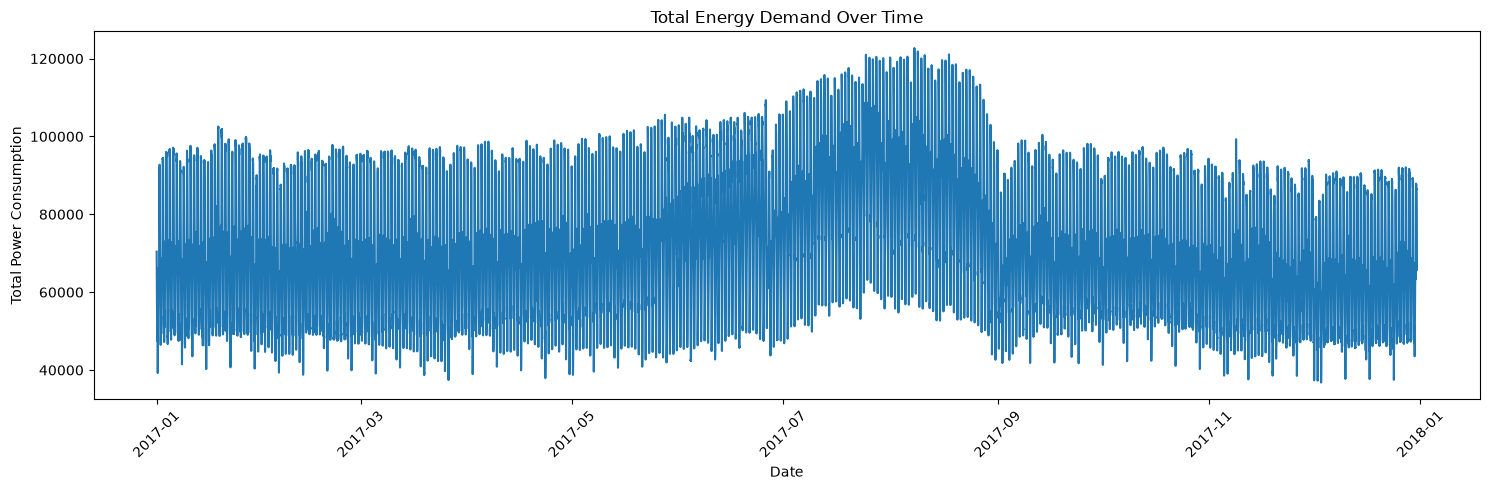

In [41]:
# Plot total energy demand over time

plt.figure(figsize=(15, 5))

plt.plot(
    df["DateTime"],
    df["Total_Demand"]
)

plt.title("Total Energy Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

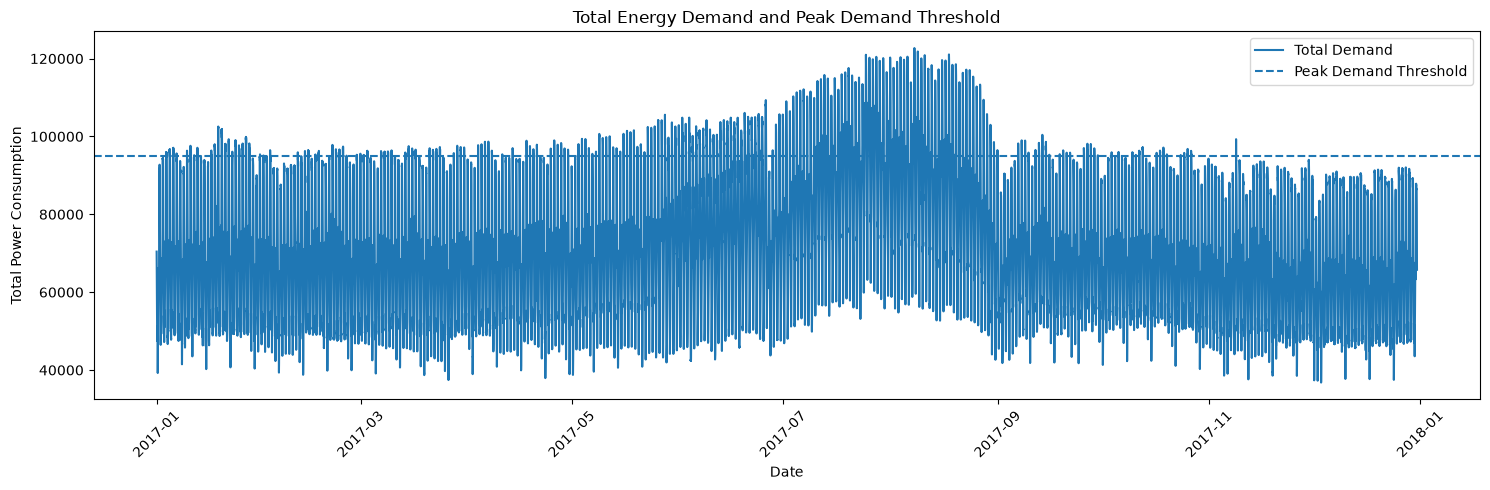

In [42]:
# Plot total demand together with the peak threshold

plt.figure(figsize=(15, 5))

plt.plot(
    df["DateTime"],
    df["Total_Demand"],
    label="Total Demand"
)

plt.axhline(
    y=peak_threshold,
    linestyle="--",
    label="Peak Demand Threshold"
)

plt.title("Total Energy Demand and Peak Demand Threshold")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [43]:
# Convert DateTime from text to datetime format

df["DateTime"] = pd.to_datetime(df["DateTime"])

# Check the data type

print(df["DateTime"].dtype)

datetime64[us]


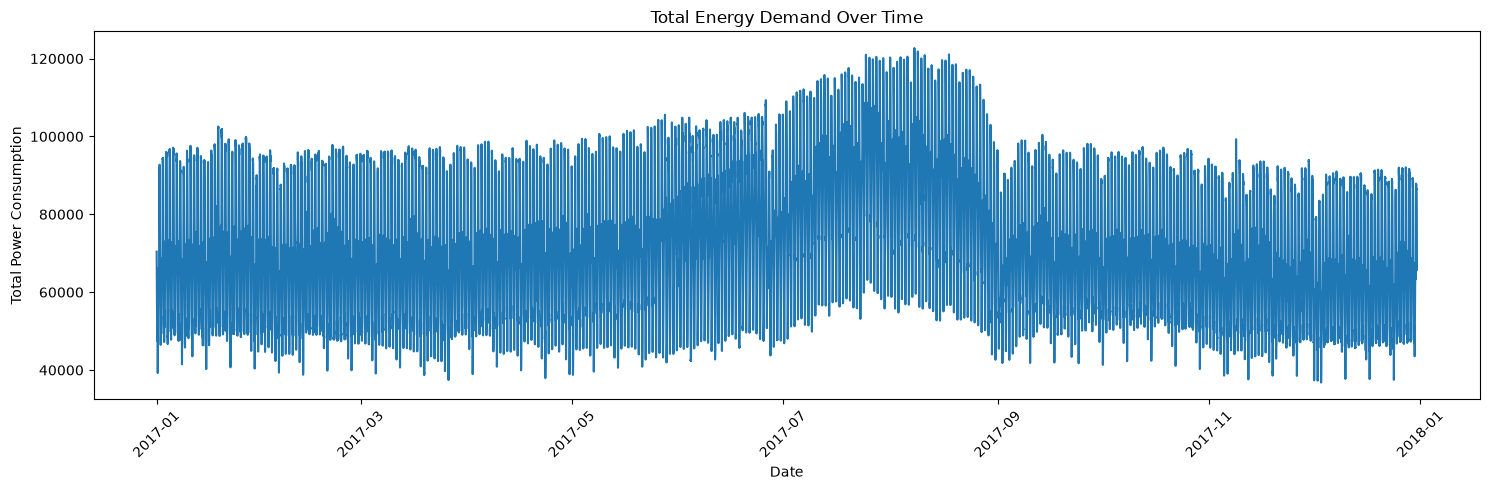

In [44]:
# Plot total energy demand over time

plt.figure(figsize=(15, 5))

plt.plot(
    df["DateTime"],
    df["Total_Demand"]
)

plt.title("Total Energy Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

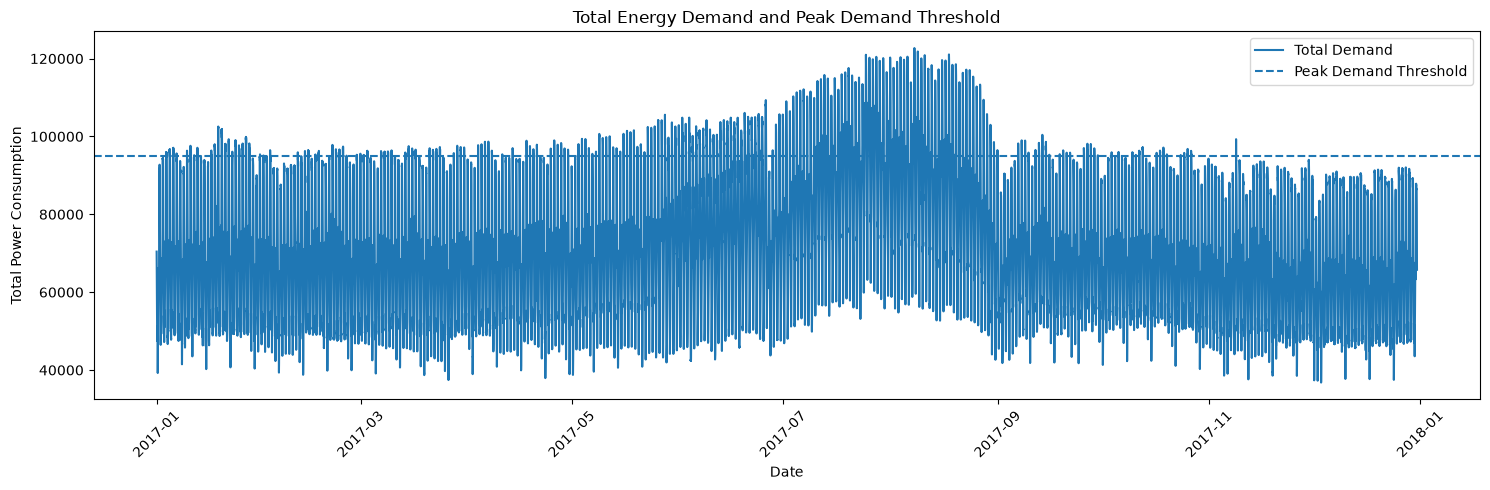

In [45]:
# Plot total demand together with the peak threshold

plt.figure(figsize=(15, 5))

plt.plot(
    df["DateTime"],
    df["Total_Demand"],
    label="Total Demand"
)

plt.axhline(
    y=peak_threshold,
    linestyle="--",
    label="Peak Demand Threshold"
)

plt.title("Total Energy Demand and Peak Demand Threshold")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

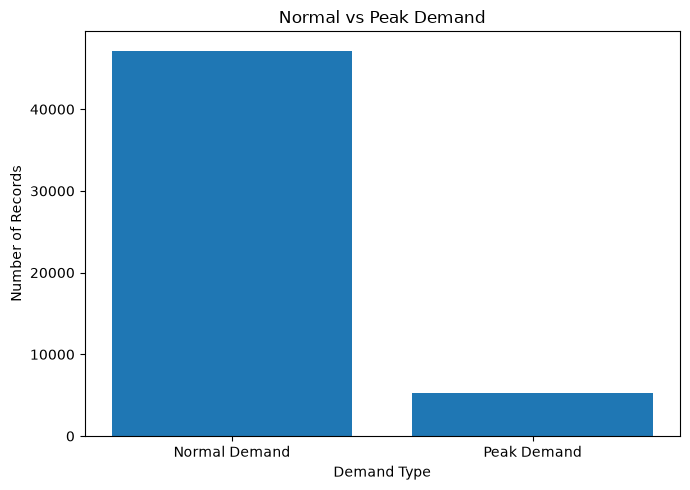

In [46]:
# Count normal and peak demand records

peak_counts = df["Peak_Demand"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Normal Demand", "Peak Demand"],
    peak_counts.values
)

plt.title("Normal vs Peak Demand")
plt.xlabel("Demand Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [47]:
# Create the target for the NEXT 10-minute period

df["Future_Peak_Demand"] = df["Peak_Demand"].shift(-1)

# Display the result

df[[
    "DateTime",
    "Total_Demand",
    "Peak_Demand",
    "Future_Peak_Demand"
]].head(10)

,DateTime,Total_Demand,Peak_Demand,Future_Peak_Demand
0,2017-01-01 00:00:00,70425.53544,0,0.0
1,2017-01-01 00:10:00,69320.84387,0,0.0
2,2017-01-01 00:20:00,67803.22193,0,0.0
3,2017-01-01 00:30:00,65489.23209,0,0.0
4,2017-01-01 00:40:00,63650.44627,0,0.0
5,2017-01-01 00:50:00,62171.34398,0,0.0
6,2017-01-01 01:00:00,60937.36065,0,0.0
7,2017-01-01 01:10:00,59566.75124,0,0.0
8,2017-01-01 01:20:00,58030.61931,0,0.0
9,2017-01-01 01:30:00,57012.92027,0,0.0


In [48]:
# Remove the final row because it has no future target

df = df.dropna(subset=["Future_Peak_Demand"])

# Convert the target to integer

df["Future_Peak_Demand"] = df["Future_Peak_Demand"].astype(int)

print("Dataset shape:", df.shape)

print("\nFuture Peak Demand distribution:")
print(df["Future_Peak_Demand"].value_counts())

Dataset shape: (52415, 56)

Future Peak Demand distribution:
Future_Peak_Demand
0    47173
1     5242
Name: count, dtype: int64


In [49]:
# Features used for predicting the next 10-minute peak

features = [

    # Weather features
    "Temperature",
    "Humidity",
    "Wind_Speed",
    "General_Diffuse_Flows",
    "Diffuse_Flows",

    # Time features
    "Hour",
    "Day_of_Week",
    "Month",
    "Quarter",
    "Is_Weekend",
    "Is_Peak_Hour",

    # Zone 1 historical demand
    "Zone_1_lag_1",
    "Zone_1_lag_6",
    "Zone_1_lag_144",
    "Zone_1_roll_mean_1h",
    "Zone_1_roll_std_1h",
    "Zone_1_roll_min_1h",
    "Zone_1_roll_max_1h",
    "Zone_1_roll_mean_24h",
    "Zone_1_roll_std_24h",
    "Zone_1_roll_min_24h",
    "Zone_1_roll_max_24h",

    # Zone 2 historical demand
    "Zone_2_lag_1",
    "Zone_2_lag_6",
    "Zone_2_lag_144",
    "Zone_2_roll_mean_1h",
    "Zone_2_roll_std_1h",
    "Zone_2_roll_min_1h",
    "Zone_2_roll_max_1h",
    "Zone_2_roll_mean_24h",
    "Zone_2_roll_std_24h",
    "Zone_2_roll_min_24h",
    "Zone_2_roll_max_24h",

    # Zone 3 historical demand
    "Zone_3_lag_1",
    "Zone_3_lag_6",
    "Zone_3_lag_144",
    "Zone_3_roll_mean_1h",
    "Zone_3_roll_std_1h",
    "Zone_3_roll_min_1h",
    "Zone_3_roll_max_1h",
    "Zone_3_roll_mean_24h",
    "Zone_3_roll_std_24h",
    "Zone_3_roll_min_24h",
    "Zone_3_roll_max_24h",

    # Temperature and humidity relationship
    "Temp_Humidity_Index",

    # Seasonal features
    "Season_Autumn",
    "Season_Spring",
    "Season_Summer",
    "Season_Winter"
]

print("Number of features:", len(features))

Number of features: 49


In [50]:
# Create input features
X = df[features]

# Create target
y = df["Future_Peak_Demand"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52415, 49)
y shape: (52415,)


In [51]:
# Check missing values in the selected features

missing_values = X.isnull().sum()

print("Features with missing values:")
print(missing_values[missing_values > 0])

Features with missing values:
Zone_1_lag_1              1
Zone_1_lag_6              6
Zone_1_lag_144          144
Zone_1_roll_mean_1h       1
Zone_1_roll_std_1h        2
Zone_1_roll_min_1h        1
Zone_1_roll_max_1h        1
Zone_1_roll_mean_24h      1
Zone_1_roll_std_24h       2
Zone_1_roll_min_24h       1
Zone_1_roll_max_24h       1
Zone_2_lag_1              1
Zone_2_lag_6              6
Zone_2_lag_144          144
Zone_2_roll_mean_1h       1
Zone_2_roll_std_1h        2
Zone_2_roll_min_1h        1
Zone_2_roll_max_1h        1
Zone_2_roll_mean_24h      1
Zone_2_roll_std_24h       2
Zone_2_roll_min_24h       1
Zone_2_roll_max_24h       1
Zone_3_lag_1              1
Zone_3_lag_6              6
Zone_3_lag_144          144
Zone_3_roll_mean_1h       1
Zone_3_roll_std_1h        2
Zone_3_roll_min_1h        1
Zone_3_roll_max_1h        1
Zone_3_roll_mean_24h      1
Zone_3_roll_std_24h       2
Zone_3_roll_min_24h       1
Zone_3_roll_max_24h       1
dtype: int64


In [52]:
# Remove rows with missing values in the selected features

data_model = df[features + ["Future_Peak_Demand"]].dropna()

print("Original number of rows:", len(df))
print("Rows available for modeling:", len(data_model))
print("Rows removed:", len(df) - len(data_model))

Original number of rows: 52415
Rows available for modeling: 52271
Rows removed: 144


In [53]:
# Create the final input features and target

X = data_model[features]

y = data_model["Future_Peak_Demand"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52271, 49)
y shape: (52271,)


In [54]:
# Check whether any missing values remain

print("Total missing values in X:", X.isnull().sum().sum())
print("Total missing values in y:", y.isnull().sum())

Total missing values in X: 0
Total missing values in y: 0


In [55]:
# Calculate the sizes for chronological splitting

total_rows = len(X)

train_size = int(total_rows * 0.70)
validation_size = int(total_rows * 0.15)

print("Total rows:", total_rows)
print("Training rows:", train_size)
print("Validation rows:", validation_size)
print("Test rows:", total_rows - train_size - validation_size)

Total rows: 52271
Training rows: 36589
Validation rows: 7840
Test rows: 7842


In [56]:
# Chronological split for input features

X_train = X.iloc[:train_size]

X_validation = X.iloc[
    train_size : train_size + validation_size
]

X_test = X.iloc[
    train_size + validation_size :
]

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

X_train: (36589, 49)
X_validation: (7840, 49)
X_test: (7842, 49)


In [57]:
# Chronological split for the target

y_train = y.iloc[:train_size]

y_validation = y.iloc[
    train_size : train_size + validation_size
]

y_test = y.iloc[
    train_size + validation_size :
]

print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)

y_train: (36589,)
y_validation: (7840,)
y_test: (7842,)


In [58]:
# Get the DateTime values corresponding to our modeling data

model_dates = df.loc[data_model.index, "DateTime"]

print("Training period:")
print(model_dates.iloc[:train_size].min())
print("to")
print(model_dates.iloc[:train_size].max())

print("\nValidation period:")
print(model_dates.iloc[train_size:train_size + validation_size].min())
print("to")
print(model_dates.iloc[train_size:train_size + validation_size].max())

print("\nTest period:")
print(model_dates.iloc[train_size + validation_size:].min())
print("to")
print(model_dates.iloc[train_size + validation_size:].max())

Training period:
2017-01-02 00:00:00
to
2017-09-13 02:00:00

Validation period:
2017-09-13 02:10:00
to
2017-11-06 12:40:00

Test period:
2017-11-06 12:50:00
to
2017-12-30 23:40:00


In [59]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_validation.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Future_Peak_Demand
0    86.285496
1    13.714504
Name: proportion, dtype: float64

Validation target distribution:
Future_Peak_Demand
0    97.193878
1     2.806122
Name: proportion, dtype: float64

Test target distribution:
Future_Peak_Demand
0    99.948993
1     0.051007
Name: proportion, dtype: float64


In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_validation_scaled = scaler.transform(X_validation)

X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_validation_scaled:", X_validation_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (36589, 49)
X_validation_scaled: (7840, 49)
X_test_scaled: (7842, 49)


In [63]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [64]:
y_validation_pred = logistic_model.predict(X_validation_scaled)

print("Validation predictions created.")

Validation predictions created.


In [65]:
print("First 20 predictions:")
print(y_validation_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

In [70]:
accuracy = accuracy_score(y_validation, y_validation_pred)
precision = precision_score(y_validation, y_validation_pred, zero_division=0)
recall = recall_score(y_validation, y_validation_pred, zero_division=0)
f1 = f1_score(y_validation, y_validation_pred, zero_division=0)

print("Logistic Regression - Validation Results")
print("----------------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Logistic Regression - Validation Results
----------------------------------------
Accuracy : 0.9797
Precision: 0.5894
Recall   : 0.9136
F1 Score : 0.7166


In [71]:
cm = confusion_matrix(y_validation, y_validation_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7480  140]
 [  19  201]]


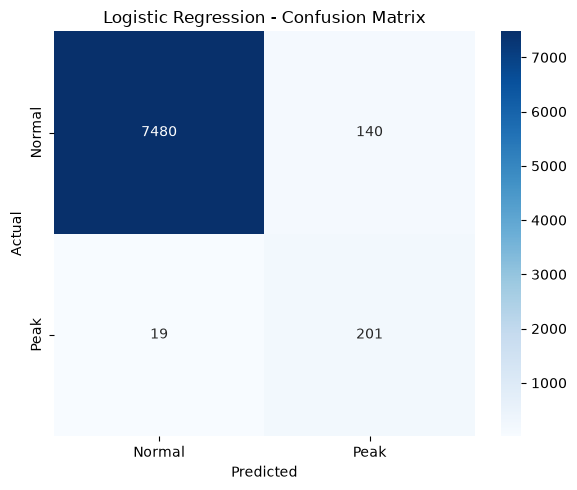

In [72]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Peak"],
    yticklabels=["Normal", "Peak"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [73]:
print("Classification Report:")
print(
    classification_report(
        y_validation,
        y_validation_pred,
        target_names=["Normal", "Peak"],
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      7620
        Peak       0.59      0.91      0.72       220

    accuracy                           0.98      7840
   macro avg       0.79      0.95      0.85      7840
weighted avg       0.99      0.98      0.98      7840



In [74]:
y_validation_proba = logistic_model.predict_proba(
    X_validation_scaled
)[:, 1]

In [75]:
roc_auc = roc_auc_score(
    y_validation,
    y_validation_proba
)

pr_auc = average_precision_score(
    y_validation,
    y_validation_proba
)

print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC :", round(pr_auc, 4))

ROC-AUC: 0.9934
PR-AUC : 0.8385


In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [78]:
y_validation_rf_pred = random_forest_model.predict(X_validation)

print("Random Forest validation predictions created.")

Random Forest validation predictions created.


In [79]:
accuracy_rf = accuracy_score(y_validation, y_validation_rf_pred)
precision_rf = precision_score(
    y_validation,
    y_validation_rf_pred,
    zero_division=0
)
recall_rf = recall_score(
    y_validation,
    y_validation_rf_pred,
    zero_division=0
)
f1_rf = f1_score(
    y_validation,
    y_validation_rf_pred,
    zero_division=0
)

print("Random Forest - Validation Results")
print("----------------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

Random Forest - Validation Results
----------------------------------
Accuracy : 0.9659
Precision: 0.445
Recall   : 0.8636
F1 Score : 0.5873


In [80]:
cm_rf = confusion_matrix(
    y_validation,
    y_validation_rf_pred
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[7383  237]
 [  30  190]]


In [81]:
print("Random Forest Classification Report:")
print(
    classification_report(
        y_validation,
        y_validation_rf_pred,
        target_names=["Normal", "Peak"],
        zero_division=0
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      7620
        Peak       0.44      0.86      0.59       220

    accuracy                           0.97      7840
   macro avg       0.72      0.92      0.78      7840
weighted avg       0.98      0.97      0.97      7840



In [82]:
y_validation_rf_proba = random_forest_model.predict_proba(
    X_validation
)[:, 1]

In [83]:
roc_auc_rf = roc_auc_score(
    y_validation,
    y_validation_rf_proba
)

pr_auc_rf = average_precision_score(
    y_validation,
    y_validation_rf_proba
)

print("ROC-AUC:", round(roc_auc_rf, 4))
print("PR-AUC :", round(pr_auc_rf, 4))

ROC-AUC: 0.9849
PR-AUC : 0.6324


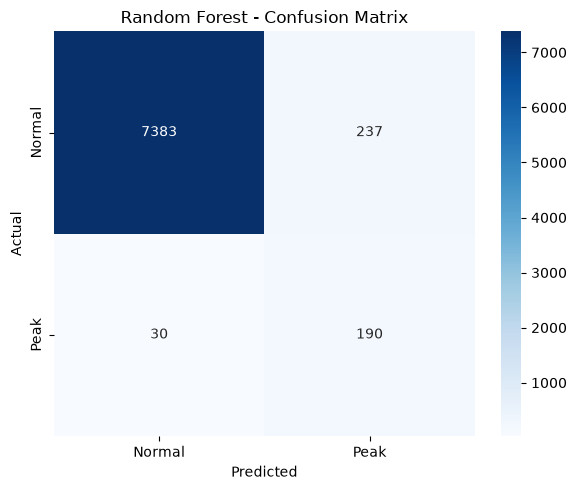

In [84]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Peak"],
    yticklabels=["Normal", "Peak"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [86]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(feature_importance.head(15))

                Feature  Coefficient  Absolute_Coefficient
33         Zone_3_lag_1     7.032714              7.032714
11         Zone_1_lag_1     6.870460              6.870460
36  Zone_3_roll_mean_1h    -6.707186              6.707186
22         Zone_2_lag_1     5.507464              5.507464
39   Zone_3_roll_max_1h     3.487502              3.487502
14  Zone_1_roll_mean_1h    -2.568070              2.568070
28   Zone_2_roll_max_1h     2.418352              2.418352
17   Zone_1_roll_max_1h     2.304774              2.304774
12         Zone_1_lag_6    -1.576258              1.576258
25  Zone_2_roll_mean_1h    -1.471263              1.471263
35       Zone_3_lag_144     1.294473              1.294473
34         Zone_3_lag_6    -1.292218              1.292218
7                 Month    -1.010091              1.010091
42  Zone_3_roll_min_24h     0.948984              0.948984
15   Zone_1_roll_std_1h    -0.838124              0.838124


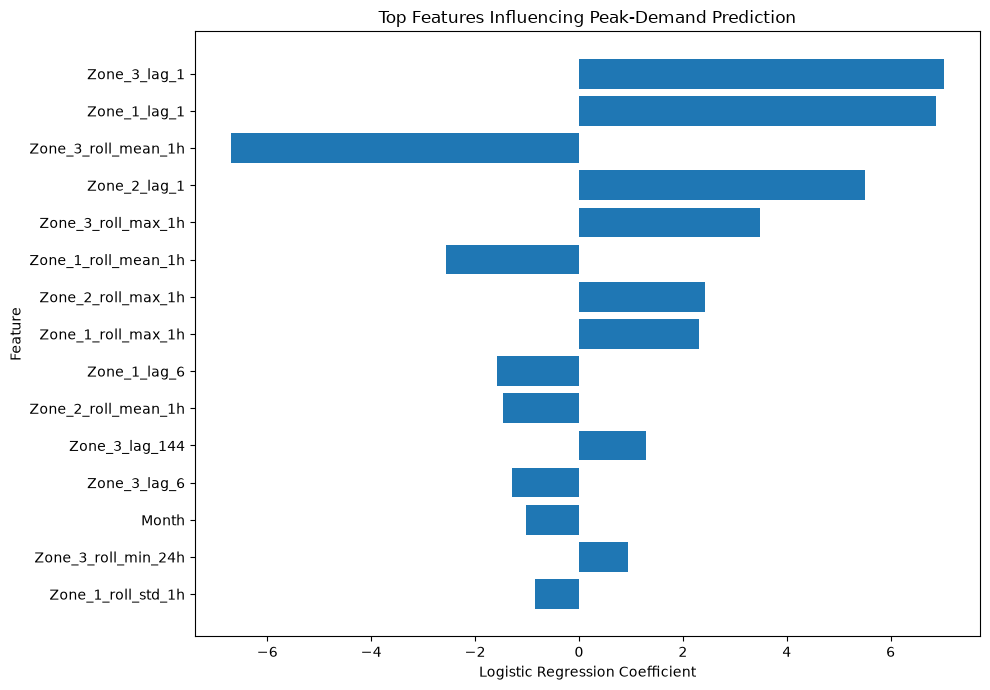

In [87]:
top_features = feature_importance.head(15).sort_values(
    "Absolute_Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Features Influencing Peak-Demand Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [88]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (
        y_validation_proba >= threshold
    ).astype(int)
    
    precision = precision_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )
    
    recall = recall_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )
    
    f1 = f1_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results = pd.DataFrame(threshold_results)

print(threshold_results)

   Threshold  Precision    Recall        F1
0       0.20   0.439583  0.959091  0.602857
1       0.25   0.467706  0.954545  0.627803
2       0.30   0.496420  0.945455  0.651017
3       0.35   0.518892  0.936364  0.667747
4       0.40   0.539474  0.931818  0.683333
5       0.45   0.571031  0.931818  0.708117
6       0.50   0.589443  0.913636  0.716578


In [89]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print("Best threshold based on F1-score:")
print(best_threshold_row)

Best threshold based on F1-score:
Threshold    0.500000
Precision    0.589443
Recall       0.913636
F1           0.716578
Name: 6, dtype: float64


In [90]:
balanced_logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

balanced_logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Balanced Logistic Regression model trained successfully.")

Balanced Logistic Regression model trained successfully.


In [91]:
y_validation_balanced_pred = balanced_logistic_model.predict(
    X_validation_scaled
)

print("Balanced Logistic Regression predictions created.")

Balanced Logistic Regression predictions created.


In [92]:
accuracy_balanced = accuracy_score(
    y_validation,
    y_validation_balanced_pred
)

precision_balanced = precision_score(
    y_validation,
    y_validation_balanced_pred,
    zero_division=0
)

recall_balanced = recall_score(
    y_validation,
    y_validation_balanced_pred,
    zero_division=0
)

f1_balanced = f1_score(
    y_validation,
    y_validation_balanced_pred,
    zero_division=0
)

print("Balanced Logistic Regression - Validation Results")
print("-------------------------------------------------")
print("Accuracy :", round(accuracy_balanced, 4))
print("Precision:", round(precision_balanced, 4))
print("Recall   :", round(recall_balanced, 4))
print("F1 Score :", round(f1_balanced, 4))

Balanced Logistic Regression - Validation Results
-------------------------------------------------
Accuracy : 0.9559
Precision: 0.3875
Recall   : 0.9864
F1 Score : 0.5564


In [93]:
cm_balanced = confusion_matrix(
    y_validation,
    y_validation_balanced_pred
)

print("Confusion Matrix:")
print(cm_balanced)

Confusion Matrix:
[[7277  343]
 [   3  217]]


In [94]:
y_validation_balanced_proba = balanced_logistic_model.predict_proba(
    X_validation_scaled
)[:, 1]

roc_auc_balanced = roc_auc_score(
    y_validation,
    y_validation_balanced_proba
)

pr_auc_balanced = average_precision_score(
    y_validation,
    y_validation_balanced_proba
)

print("ROC-AUC:", round(roc_auc_balanced, 4))
print("PR-AUC :", round(pr_auc_balanced, 4))

ROC-AUC: 0.9925
PR-AUC : 0.7918


In [95]:
y_test_pred = logistic_model.predict(X_test_scaled)

y_test_proba = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Final test predictions created.")

Final test predictions created.


In [96]:
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print("Final Logistic Regression - Test Results")
print("-----------------------------------------")
print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall   :", round(test_recall, 4))
print("F1 Score :", round(test_f1, 4))
print("ROC-AUC  :", round(test_roc_auc, 4))
print("PR-AUC   :", round(test_pr_auc, 4))

Final Logistic Regression - Test Results
-----------------------------------------
Accuracy : 0.9991
Precision: 0.2857
Recall   : 0.5
F1 Score : 0.3636
ROC-AUC  : 0.9778
PR-AUC   : 0.5283


In [97]:
cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print("Final Test Confusion Matrix:")
print(cm_test)

Final Test Confusion Matrix:
[[7833    5]
 [   2    2]]


In [98]:
print("Final Test Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Normal", "Peak"],
        zero_division=0
    )
)

Final Test Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7838
        Peak       0.29      0.50      0.36         4

    accuracy                           1.00      7842
   macro avg       0.64      0.75      0.68      7842
weighted avg       1.00      1.00      1.00      7842



In [100]:
monthly_peak_summary = df.groupby("Month")["Peak_Demand"].agg(
    Total_Records="count",
    Peak_Records="sum"
)

monthly_peak_summary["Peak_Percentage"] = (
    monthly_peak_summary["Peak_Records"]
    / monthly_peak_summary["Total_Records"]
    * 100
)

print(monthly_peak_summary)

       Total_Records  Peak_Records  Peak_Percentage
Month                                              
1               4464           331         7.414875
2               4032           124         3.075397
3               4464           188         4.211470
4               4320           172         3.981481
5               4464           397         8.893369
6               4320           729        16.875000
7               4464          1628        36.469534
8               4464          1375        30.801971
9               4320           185         4.282407
10              4464           109         2.441756
11              4320             4         0.092593
12              4319             0         0.000000


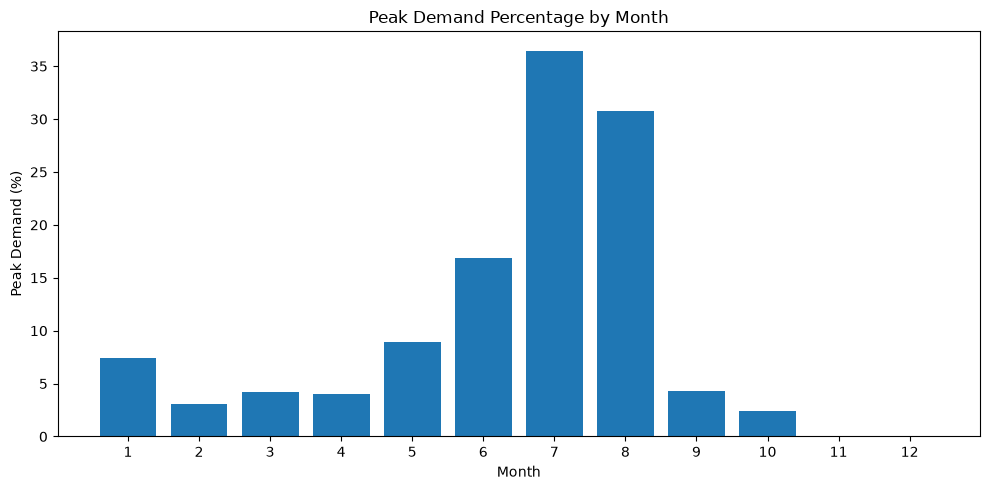

In [101]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_peak_summary.index.astype(str),
    monthly_peak_summary["Peak_Percentage"]
)

plt.title("Peak Demand Percentage by Month")
plt.xlabel("Month")
plt.ylabel("Peak Demand (%)")

plt.tight_layout()
plt.show()

In [102]:
monthly_demand = df.groupby("Month")["Total_Demand"].agg(
    Average_Demand="mean",
    Maximum_Demand="max",
    Minimum_Demand="min"
)

print(monthly_demand)

       Average_Demand  Maximum_Demand  Minimum_Demand
Month                                                
1        68173.033601   102522.191330    39239.457920
2        67108.548882    97835.103190    38782.313450
3        66560.788896    97613.263580    37436.222842
4        67396.902281    98978.251360    37933.393604
5        69994.397979   105576.678090    38750.537800
6        75707.410998   109331.747580    42361.915613
7        87315.214499   120976.080695    46882.512140
8        85446.466933   122699.906485    42642.153285
9        68499.912449   100417.581100    41753.412449
10       67560.748669    97225.706530    40261.433582
11       65105.067506    99297.464590    37610.398433
12       63750.364163    92049.837650    36785.039739


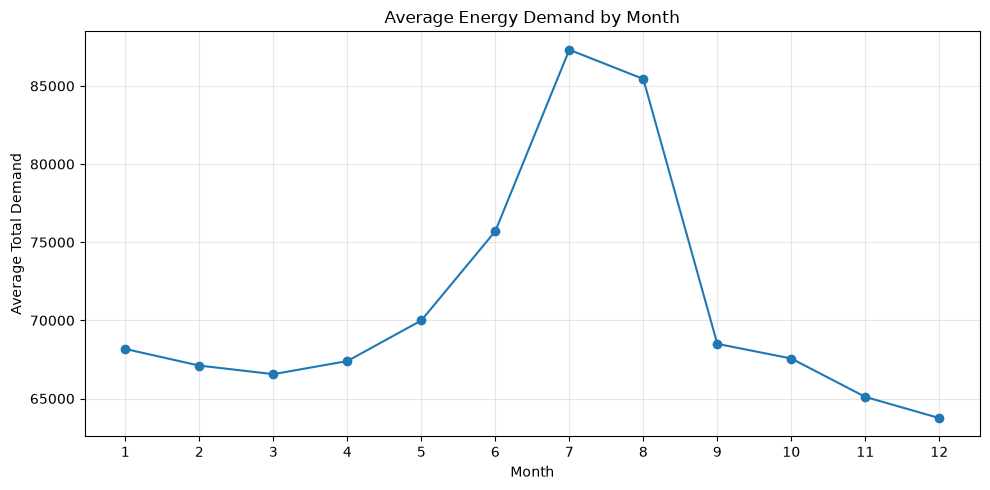

In [104]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand["Average_Demand"],
    marker="o"
)

plt.title("Average Energy Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Total Demand")

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [105]:
# Find the last date/time in the training period
training_end_datetime = df.loc[X_train.index, "DateTime"].max()

print("Training period ends at:", training_end_datetime)

Training period ends at: 2017-09-13 02:00:00


In [106]:
# Calculate the 90th percentile using training data only
training_threshold = df.loc[
    df["DateTime"] <= training_end_datetime,
    "Total_Demand"
].quantile(0.90)

print("Global threshold:", peak_threshold)
print("Training-only threshold:", training_threshold)

Global threshold: 94912.14182
Training-only threshold: 96999.27257600002


In [107]:
# Create peak labels using the training-only threshold
df["Peak_Demand_TrainThreshold"] = (
    df["Total_Demand"] >= training_threshold
).astype(int)

# Create the future peak target
df["Future_Peak_Demand_TrainThreshold"] = (
    df["Peak_Demand_TrainThreshold"].shift(-1)
)

# Check the overall distribution
print(
    df["Future_Peak_Demand_TrainThreshold"]
    .value_counts(dropna=False)
)

Future_Peak_Demand_TrainThreshold
0.0    48692
1.0     3722
NaN        1
Name: count, dtype: int64


In [108]:
# Get the alternative target for the test period
alternative_test_target = df.loc[
    X_test.index,
    "Future_Peak_Demand_TrainThreshold"
].dropna().astype(int)

print("Alternative test target distribution:")
print(alternative_test_target.value_counts())

print("\nAlternative test target percentage:")
print(
    alternative_test_target.value_counts(normalize=True) * 100
)

Alternative test target distribution:
Future_Peak_Demand_TrainThreshold
0    7838
1       3
Name: count, dtype: int64

Alternative test target percentage:
Future_Peak_Demand_TrainThreshold
0    99.96174
1     0.03826
Name: proportion, dtype: float64


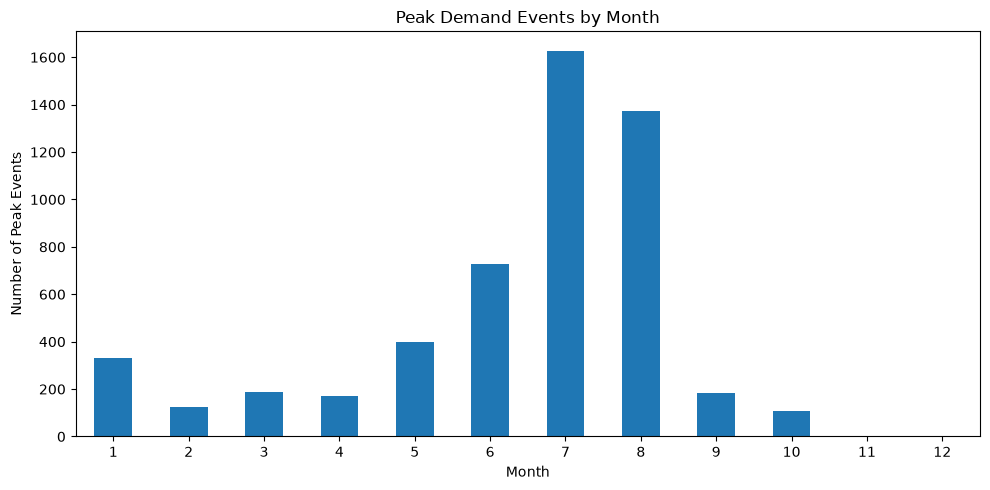

In [109]:
# Monthly peak-demand distribution

monthly_peak = df.groupby("Month")["Peak_Demand"].sum()

plt.figure(figsize=(10, 5))
monthly_peak.plot(kind="bar")

plt.title("Peak Demand Events by Month")
plt.xlabel("Month")
plt.ylabel("Number of Peak Events")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

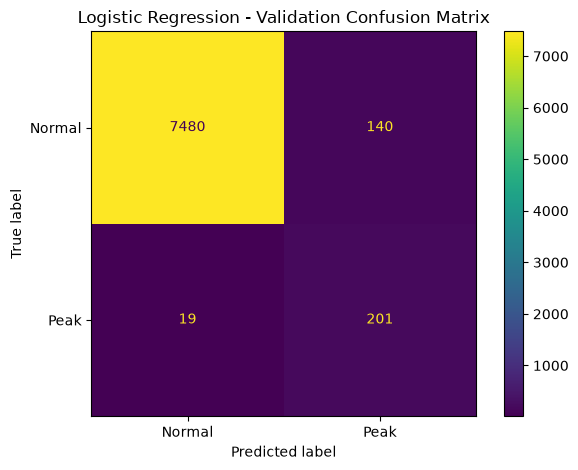

In [110]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    y_validation_pred,
    display_labels=["Normal", "Peak"]
)

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

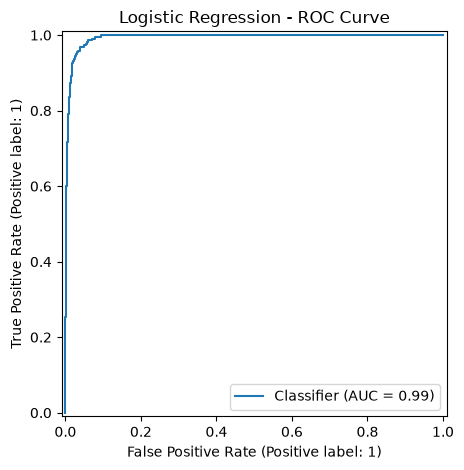

In [111]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_validation,
    y_validation_proba
)

plt.title("Logistic Regression - ROC Curve")
plt.tight_layout()
plt.show()

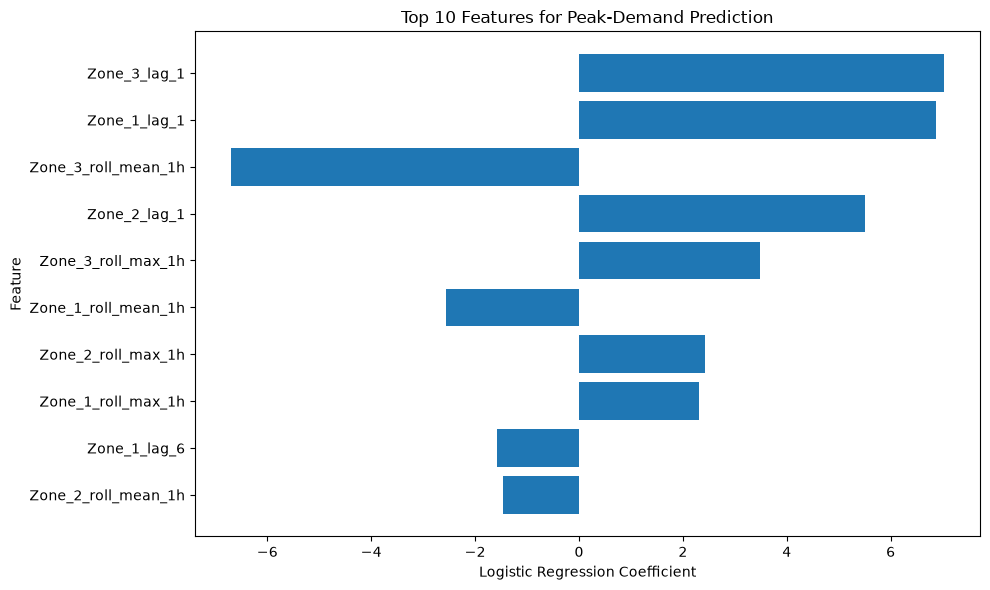

In [112]:
# Top 10 most influential features

top_features = feature_importance.head(10).sort_values(
    "Absolute_Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top 10 Features for Peak-Demand Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()